# Import Libraries

Import the required Python libraries for data analysis, visualization, exploratory data analysis, preprocessing, model training, and evaluation.

### Libraries Used

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from ydata_profiling import ProfileReport
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder

Loading Dataset

In [2]:
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

Data Inspection

In [3]:
train.shape

(188318, 132)

In [4]:
test.shape 

(125546, 131)

In [5]:
test.isna().sum().any()

False

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188318 entries, 0 to 188317
Columns: 132 entries, id to loss
dtypes: float64(15), int64(1), object(116)
memory usage: 189.7+ MB


In [8]:
train.sample(4)

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
97910,306179,A,B,A,A,A,A,A,A,A,...,0.680324,0.842588,0.25010,0.61751,0.78770,0.603774,0.590961,0.372852,0.381660,349.96
29779,93477,A,A,A,A,A,B,A,A,A,...,0.897312,0.671122,0.80438,0.93884,0.80218,0.776962,0.764426,0.854872,0.471352,1311.92
1272,4136,A,B,A,B,A,A,A,A,B,...,0.294756,0.172881,0.37194,0.41471,0.32935,0.245410,0.270746,0.533284,0.411332,1617.21
109640,342349,A,A,A,A,A,B,A,A,A,...,0.220282,0.303334,0.27797,0.38249,0.31003,0.245410,0.241676,0.298734,0.358084,712.48


In [11]:
train.isna().sum().sum()

0

In [13]:
train.describe(include='all')

,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
count,188318.000000,188318,188318,188318,188318,188318,188318,188318,188318,188318,...,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000
unique,NaN,2,2,2,2,2,2,2,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,A,A,A,A,A,A,A,A,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,141550,106721,177993,128395,123737,131693,183744,177274,113122,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,294135.982561,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.490945,0.484970,0.486437,0.485506,0.498066,0.493511,0.493150,0.493138,0.495717,3037.337686
std,169336.084867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.205273,0.178450,0.199370,0.181660,0.185877,0.209737,0.209427,0.212777,0.222488,2904.086186
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.012683,0.069503,0.236880,0.000080,0.000000,0.035321,0.036232,0.000228,0.179722,0.670000
25%,147748.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.336105,0.350175,0.312800,0.358970,0.364580,0.310961,0.311661,0.315758,0.294610,1204.460000
50%,294539.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.440945,0.438285,0.441060,0.441450,0.461190,0.457203,0.462286,0.363547,0.407403,2115.570000
75%,440680.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.655021,0.591045,0.623580,0.566820,0.614590,0.678924,0.675759,0.689974,0.724623,3864.045000


### Pandas Profiling Report Initialization

Generates a comprehensive exploratory data analysis (EDA) report for the training dataset.

In [5]:
profile = ProfileReport(train, title="Profiling Report")

In [8]:
profile.to_file("data_profile_report.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Target Variable Summary Statistics

Computes and displays descriptive statistics for the `loss` column in the training dataset to understand its distribution.

In [7]:
print(train['loss'].describe())

count    188318.000000
mean       3037.337686
std        2904.086186
min           0.670000
25%        1204.460000
50%        2115.570000
75%        3864.045000
max      121012.250000
Name: loss, dtype: float64


In [14]:
print("Median:",train['loss'].median())


Median: 2115.5699999999997


In [15]:
print("Skew:",train['loss'].skew())

Skew: 3.7949583775378604


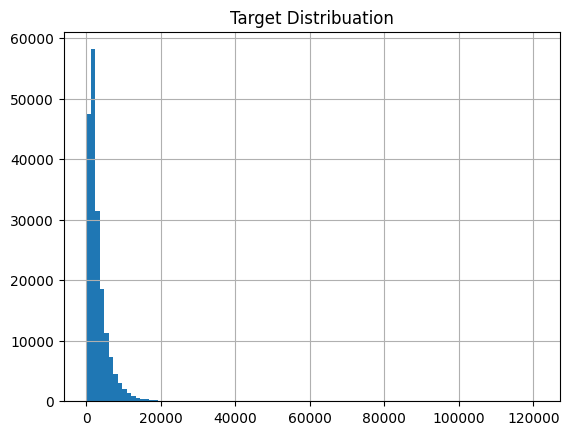

In [22]:
train['loss'].hist(bins=100)
plt.title("Target Distribution")
plt.show()

### Continuous Feature Identification

List comprehension to isolate continuous variable columns based on a specific naming convention.

In [3]:
cont_cols = [c for c in train.columns if c.startswith('cont')]

In [4]:
train[cont_cols].nunique()

cont1       647
cont2        33
cont3        76
cont4       112
cont5       141
cont6      2573
cont7      5632
cont8       201
cont9       347
cont10      174
cont11      326
cont12      328
cont13      353
cont14    18740
dtype: int64

In [20]:
train[cont_cols].describe()

,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14
count,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000,188318.000000
mean,0.493861,0.507188,0.498918,0.491812,0.487428,0.490945,0.484970,0.486437,0.485506,0.498066,0.493511,0.493150,0.493138,0.495717
std,0.187640,0.207202,0.202105,0.211292,0.209027,0.205273,0.178450,0.199370,0.181660,0.185877,0.209737,0.209427,0.212777,0.222488
min,0.000016,0.001149,0.002634,0.176921,0.281143,0.012683,0.069503,0.236880,0.000080,0.000000,0.035321,0.036232,0.000228,0.179722
25%,0.346090,0.358319,0.336963,0.327354,0.281143,0.336105,0.350175,0.312800,0.358970,0.364580,0.310961,0.311661,0.315758,0.294610
50%,0.475784,0.555782,0.527991,0.452887,0.422268,0.440945,0.438285,0.441060,0.441450,0.461190,0.457203,0.462286,0.363547,0.407403
75%,0.623912,0.681761,0.634224,0.652072,0.643315,0.655021,0.591045,0.623580,0.566820,0.614590,0.678924,0.675759,0.689974,0.724623
max,0.984975,0.862654,0.944251,0.954297,0.983674,0.997162,1.000000,0.980200,0.995400,0.994980,0.998742,0.998484,0.988494,0.844848


### Categorical Feature Identification

List comprehension to isolate categorical variable columns based on their naming convention.

In [5]:
cat_cols = [c for c in train.columns if c.startswith('cat')]

In [10]:
train[cat_cols].nunique()

cat1        2
cat2        2
cat3        2
cat4        2
cat5        2
         ... 
cat112     51
cat113     61
cat114     19
cat115     23
cat116    326
Length: 116, dtype: int64

In [12]:
train[cat_cols].nunique().sort_values(ascending=False).head(15)

cat116    326
cat110    131
cat109     84
cat113     61
cat112     51
cat115     23
cat107     20
cat105     20
cat101     19
cat114     19
cat106     17
cat104     17
cat111     16
cat99      16
cat100     15
dtype: int64

### Categorical Feature Mismatch Check

Identifies inconsistencies between the unique categories present in the training set versus the test set.

In [13]:
mismatch_report=[]
for col in cat_cols:
    train_vals=set(train[col].unique())
    test_vals=set(test[col].unique())
    only_in_test= test_vals - train_vals
    only_in_train= train_vals - test_vals
    if only_in_test or only_in_train:
        mismatch_report.append({
            'column':col,
            'only_in_test': len(only_in_test),
            'only_in_train': len(only_in_train),
            'test_example': list(only_in_test)[:3]
        })

In [14]:
pd.DataFrame(mismatch_report)

,column,only_in_test,only_in_train,test_example
0,cat89,1,1,[F]
1,cat90,0,1,[]
2,cat92,2,1,"[E, G]"
3,cat96,1,0,[H]
4,cat99,1,0,[U]
5,cat101,0,2,[]
6,cat102,0,2,[]
7,cat103,1,0,[M]
8,cat105,0,2,[]
9,cat106,1,0,[Q]


In [6]:
train['log_loss']= np.log1p(train['loss'])

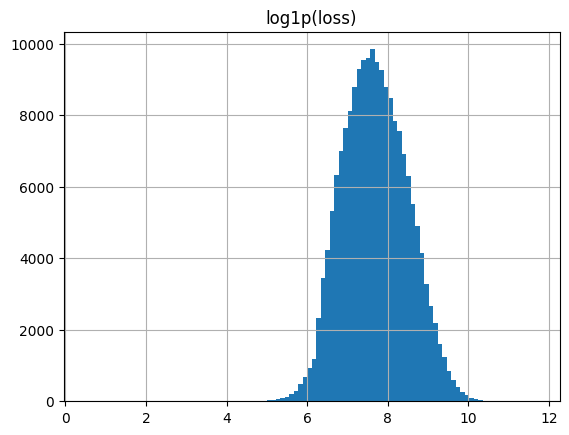

In [7]:
train['log_loss'].hist(bins=100)
plt.title('log1p(loss)')
plt.show()

### Ordinal encoding

Encode categoricals; unseen test categories map to `-1`.

In [9]:
feature_cols = [c for c in train.columns if c not in ['id', 'loss', 'log_loss']]
cat_cols = [c for c in feature_cols if c.startswith('cat')]
X = train[feature_cols].copy()
y = train['log_loss']

### 5-fold cross-validation

Train LightGBM and report MAE on original `loss` scale.

In [11]:
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
X[cat_cols] = encoder.fit_transform(X[cat_cols]).astype(int)

### Encode test features

Apply the same encoder fitted on train.

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds_log = np.zeros(len(train))
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )
    model.fit(X_tr, y_tr)
    pred_log = model.predict(X_val)
    oof_preds_log[val_idx] = pred_log
    mae = mean_absolute_error(
        train['loss'].iloc[val_idx],
        np.expm1(pred_log)
    )
    print(f"Fold {fold + 1} MAE: {mae:.2f}")

overall_mae = mean_absolute_error(train['loss'], np.expm1(oof_preds_log))
print(f"\nOverall OOF MAE: {overall_mae:.2f}")

Fold 1 MAE: 1138.74
Fold 2 MAE: 1157.36
Fold 3 MAE: 1152.81
Fold 4 MAE: 1150.39
Fold 5 MAE: 1138.71


### Train final LightGBM model

Fit on full training data for test predictions.

In [13]:
X_test = test[feature_cols].copy()
X_test[cat_cols] = encoder.transform(X_test[cat_cols]).astype(int)

### LightGBM submission

Save `submission.csv` for Kaggle.

In [14]:
final_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
final_model.fit(X, y)
test_pred_log = final_model.predict(X_test)
test_pred_loss = np.expm1(test_pred_log)

## CatBoost experiment (optional)

CatBoost handles raw categorical strings natively.

In [15]:
submission = pd.DataFrame({
    'id': test['id'],
    'loss': test_pred_loss
})
submission.to_csv('submission.csv', index=False)

print('Rows:', len(submission), '| Test rows:', len(test))
print('Any negative?', (submission['loss'] < 0).any())
print('Any NaN?', submission['loss'].isna().any())
submission.head()

,id,loss
0,4,1528.905719
1,6,2108.867724
2,9,9149.406656
3,12,5710.307212
4,15,820.742766


### Train CatBoost

80/20 validation split; evaluate MAE on original scale.

In [21]:
# CatBoost works best with raw categorical strings (not OrdinalEncoder output)
X_raw = train[feature_cols].copy()
cat_feature_indices = [X_raw.columns.get_loc(c) for c in cat_cols]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    random_state=42
)

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

pred_log = cat_model.predict(X_valid)
mae = mean_absolute_error(np.expm1(y_valid), np.expm1(pred_log))
print(f"\nValidation MAE: {mae:.4f}")

0:	learn: 0.7965524	test: 0.7920758	best: 0.7920758 (0)	total: 320ms	remaining: 2m 39s
100:	learn: 0.5543552	test: 0.5517846	best: 0.5517846 (100)	total: 33.2s	remaining: 2m 11s
200:	learn: 0.5423238	test: 0.5420469	best: 0.5420469 (200)	total: 1m 7s	remaining: 1m 40s
300:	learn: 0.5351836	test: 0.5376208	best: 0.5376208 (300)	total: 1m 52s	remaining: 1m 14s
400:	learn: 0.5306511	test: 0.5355146	best: 0.5355146 (400)	total: 3m	remaining: 44.6s
499:	learn: 0.5273549	test: 0.5342424	best: 0.5342424 (499)	total: 4m 30s	remaining: 0us

bestTest = 0.5342423655
bestIteration = 499


Validation MAE: 1141.0778


### CatBoost submission

Save `catboost_submission1.csv`.

In [22]:
X_test_raw = test[feature_cols].copy()
pred_log = cat_model.predict(X_test_raw)
pred_loss = np.expm1(pred_log)

catboost_submission = pd.DataFrame({
    'id': test['id'],
    'loss': pred_loss
})
catboost_submission.to_csv('catboost_submission1.csv', index=False)
catboost_submission.head()

   id         loss
0   4  3572.829033
1   6  4239.824844
2   9  4001.520888
3  12  4090.147007
4  15  4123.307801


### End

Notebook complete.